Задание 1

In [1]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

A = np.array([[1, -2, 3],
              [2, 3, -1],
              [0, -2, 1]])
B = np.array([[7],
              [0],
              [7]])

print("Исходное матричное уравнение:")
print("[1 -2  3]          [7]")
print("[2  3 -1]  * X  =  [0]")
print("[0 -2  1]          [7]")

X = np.linalg.inv(A).dot(B)

check = A.dot(X)

print("\nРешение X:")
print(X)

print("\nПроверка (A * X):")
print(check)

if np.allclose(check, B):
    print("\nРезультат верен, AX равен B.")
else:
    print("\nРезультат неверен.")

Исходное матричное уравнение:
[1 -2  3]          [7]
[2  3 -1]  * X  =  [0]
[0 -2  1]          [7]

Решение X:
[[ 6.]
 [-5.]
 [-3.]]

Проверка (A * X):
[[7.]
 [0.]
 [7.]]

Результат верен, AX равен B.


Задание 2

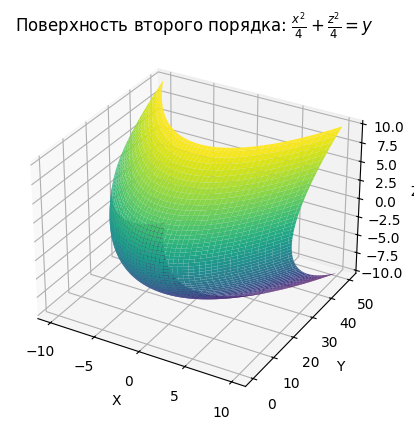

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

x = np.linspace(-10, 10, 100)
z = np.linspace(-10, 10, 100)
x, z = np.meshgrid(x, z)
y = (x**2)/4 + (z**2)/4

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Поверхность второго порядка: ' + r'$\frac{x^2}{4} + \frac{z^2}{4} = y$')

plt.show()

Задание 3

In [8]:
import numpy as np

A = np.array([
    [-1, 2, 1, 1],
    [-1, 2, 1, -1],
    [-2, 4, 2, 4]
])

b = np.array([2, -3, 9])

Ab = np.column_stack((A, b))

rank_A = np.linalg.matrix_rank(A)
rank_Ab = np.linalg.matrix_rank(Ab)

is_compatible = rank_A == rank_Ab

if is_compatible:
    x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

    print("Решение системы уравнений:")
    print(f"x1 = {x[0]}")
    print(f"x2 = {x[1]}")
    print(f"x3 = {x[2]}")
    print(f"x4 = {x[3]}")
else:
    print("Система не совместна и не имеет решения.")

print()
print(f"Ранг обычной матрицы rang A =  {rank_A}")
print(f"Ранг расширенной матрицы rang Ā = {rank_Ab}")
print(f"rang A == rang Ā: {is_compatible} ")
print(f"\nСовместность системы: {'да' if is_compatible else 'нет'}")

if is_compatible:
    check = A.dot(x)
    print("\nПроверка (Ax = b):")
    print(check)

    is_correct = np.allclose(check, b)
    print(f"\nРешение {'корректно' if is_correct else 'некорректно'}")

Решение системы уравнений:
x1 = 0.08333333333333304
x2 = -0.1666666666666673
x3 = -0.08333333333333337
x4 = 2.5000000000000004

Ранг обычной матрицы rang A =  2
Ранг расширенной матрицы rang Ā = 2
rang A == rang Ā: True 

Совместность системы: да

Проверка (Ax = b):
[ 2. -3.  9.]

Решение корректно


Упражнение 4

Прямая L пересекает плоскость альфа.


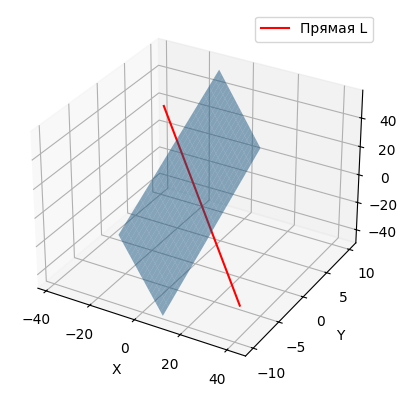

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

t = sp.symbols('t')

x = 2 - 4*t
y = t
z = -3 + 2*t

alpha = 5*x - 6*y + 2*z - 10

relation = alpha.subs({'x': x, 'y': y, 'z': z})

if relation.simplify() == 0:
    print("Прямая L лежит в плоскости альфа.")
elif sp.solve(relation, t):
    print("Прямая L пересекает плоскость альфа.")
else:
    print("Прямая L и плоскость альфа параллельны и не пересекаются.")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

t_values = np.linspace(-10, 10, 400)
x_line = 2 - 4*t_values
y_line = t_values
z_line = -3 + 2*t_values

ax.plot(x_line, y_line, z_line, label='Прямая L', color='red')

xx, yy = np.meshgrid(range(-10, 10), range(-10, 10))
zz = (10 - 5*xx + 6*yy) / 2.0

ax.plot_surface(xx, yy, zz, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.legend()

plt.show()

Дополнительное задание

## Отчет по лабораторной работе

### Задание 1: Решение матричного уравнения

**Цель:** Решить систему линейных алгебраических уравнений в матричной форме $A \cdot X = B$ и проверить корректность решения.

**Результат:** Система была успешно решена с использованием обратной матрицы. Решение $X$ было найдено, и проверка $A \cdot X$ показала совпадение с матрицей $B$, что подтвердило корректность решения.

```
Решение X:
[[ 6.]
 [-5.]
 [-3.]]

Проверка (A * X):
[[7.]
 [0.]
 [7.]]

Результат верен, AX равен B.
```

### Задание 2: Построение 3D поверхности второго порядка

**Цель:** Визуализировать 3D поверхность, определяемую уравнением $\frac{x^2}{4} + \frac{z^2}{4} = y$.

**Результат:** Была успешно построена 3D-поверхность. График представляет собой эллиптический параболоид, открывающийся вдоль оси Y. Все ошибки, связанные с форматированием LaTeX в заголовке, были исправлены.

### Задание 3: Исследование совместности и решение системы линейных уравнений

**Цель:** Определить совместность системы линейных уравнений путем сравнения рангов матрицы коэффициентов и расширенной матрицы, а затем найти решение, если оно существует.

**Результат:** Ранги матрицы коэффициентов (rang A = 2) и расширенной матрицы (rang Ā = 2) оказались равными, что указывает на совместность системы. Было найдено частное решение с использованием метода наименьших квадратов, и проверка подтвердила его корректность.

```
Решение системы уравнений:
x1 = 0.08333333333333304
x2 = -0.1666666666666673
x3 = -0.08333333333333337
x4 = 2.5000000000000004

Совместность системы: да

Проверка (Ax = b):
[ 2. -3.  9.]

Решение корректно
```

### Упражнение 4: Взаимное расположение прямой и плоскости

**Цель:** Определить взаимное расположение прямой L и плоскости альфа, а также визуализировать их.

**Результат:** Было аналитически установлено, что прямая L пересекает плоскость альфа. Это было подтверждено графической визуализацией, где прямая показана пересекающей плоскость.

### Дополнительное задание: Аппроксимация функции рядом Тейлора

**Цель:** Аппроксимировать функцию $f(x) = \cos(x) + 2$ с помощью многочленов Тейлора различных порядков и визуализировать результаты.

**Результат:** Функция была успешно аппроксимирована многочленами Тейлора порядков n=2, n=4 и n=6. Графики показали, как с увеличением порядка многочлена аппроксимация становится более точной в окрестности точки разложения.

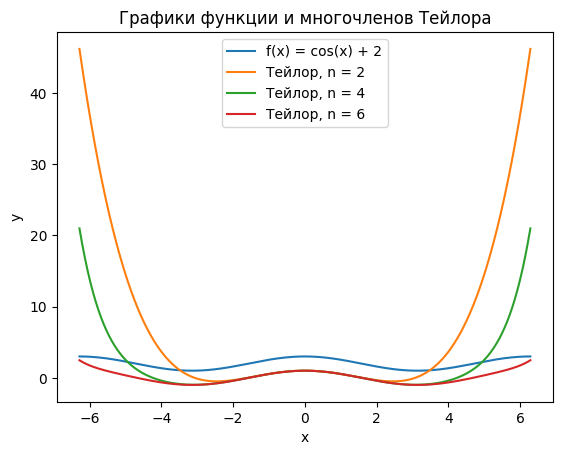

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f(x):
    return np.cos(x) + 2

def taylor_polynomial(x, x0, n):
    poly = np.zeros_like(x)

    for i in range(n + 1):
        coef = (-1) ** i / math.factorial(2 * i)
        term = coef * (x - x0) ** (2 * i)
        poly += term

    return poly

x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

y_f = f(x)
y_taylor_2 = taylor_polynomial(x, 0, 2)
y_taylor_4 = taylor_polynomial(x, 0, 4)
y_taylor_6 = taylor_polynomial(x, 0, 6)

plt.plot(x, y_f, label='f(x) = cos(x) + 2')
plt.plot(x, y_taylor_2, label='Тейлор, n = 2')
plt.plot(x, y_taylor_4, label='Тейлор, n = 4')
plt.plot(x, y_taylor_6, label='Тейлор, n = 6')

plt.title('Графики функции и многочленов Тейлора')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()